# Lógica difusa

## Introducción

La **lógica difusa *(fuzzy logic)*** nace del intento de modelar el razonamiento de una forma similar a la que tenemos las personas al explicarnos. Cuando alguien tiene calor, no dice que tiene $0.78$ unidades de calor, dice que tiene *mucho* calor, o *un poco de* calor, incluso *demasiado* calor. 

Todos estos calificativos son válidos y comprensibles, pero **relacionarlo con una temperatura exacta**, como 32ºC, no es trivial: ¿sería *mucho*, *un poco de*, o *demasiado* calor? Esta es la idea que vamos a ver cómo modelar.

## Modelo


### Conjunto difuso

En lógica clásica, se define un **conjunto** como el grupo de elementos que satisfacen la siguiente propiedad:

$$S_C: \mathcal{D} \rightarrow \{0,1\}$$

donde:
* $\mathcal{D}$ es el dominio sobre el que se trabaja
* $\{0,1\}$ es una salida binaria, donde 0 indica que no se satisface la condición y 1 que se satisface la condición

La función $S_C$ es la que define qué forma parte del conjunto y qué no. Por ejemplo:

$$S_{num\_pares}: \mathbb{Z} \rightarrow \{0,1\} = z \text{ mod } 2 \mid \forall z \in \mathbb{Z}$$

En lógica difusa, se define un **conjunto *difuso*** como el grupo de elementos que satisfacen la siguiente propiedad:

$$S_F: \mathcal{D} \rightarrow [0,1]$$

donde:
* $\mathcal{D}$ es el dominio sobre el que se trabaja
* $[0,1]$ es un **rango**, donde 0 indica que no se satisface la condición, (0,1) indica que se satisface la condición parcialmente, y 1 que se satisface la condición totalmente

Las funciones que definen estos conjuntos se denominan **funciones de pertenencia**:

$$\mu_{S_F}(v) \in [0,1] \mid v \in \mathcal{D}$$

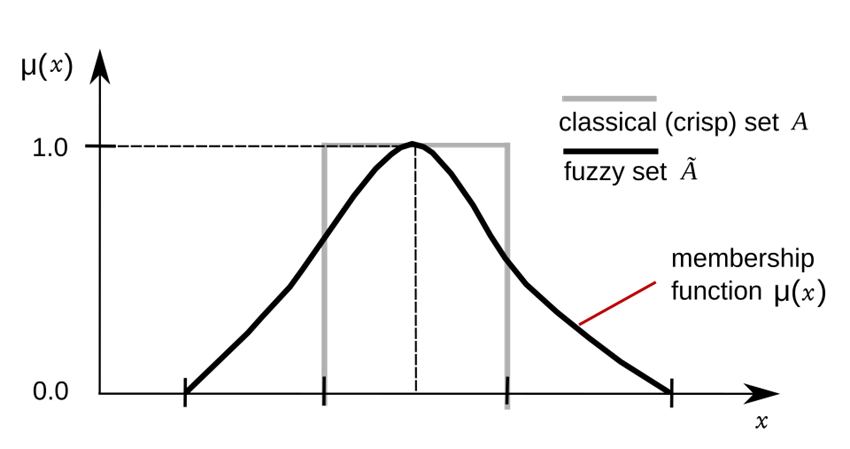

A lo largo de la literatura se pueden encontrar funciones de pertenencia "estándar":

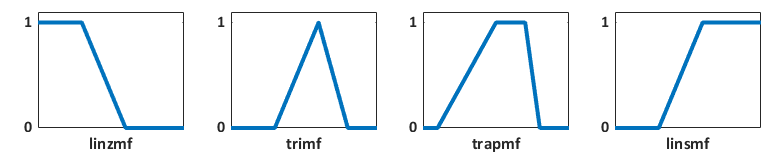

#### Ejercicio 1

Implementa una función de pertenencia clásica para el conjunto de los números entre 0 y 10, y una función de pertenencia difusa triangular para el conjunto de números que están cerca del 5 (utiliza [0,10] como límites izquierdo y derecho).

In [ ]:
def mf_between_zero_and_ten(n):
    ### YOUR CODE HERE
    pass

def mf_close_to_five(n):
    ### YOUR CODE HERE
    pass

### Variable difusa

Aplicando el concepto de conjunto difuso, se define una **variable difusa** como un conjunto de conjuntos difusos, donde cada uno de ellos representa una etiqueta lingüísitca asociada a al hecho que representa:

$$x = \{X_F^1, X_F^2, \dots, X_F^n\} \mid X_F^i: \mathcal{D}_x \rightarrow [0,1]$$

$$\mathcal{D}_x = [x_{min}, x_{max}]$$

$$\mu_{X_F^i}(v) \in [0,1] \mid v \in [x_{min}, x_{max}]$$

Con el ejemplo de la temperatura:

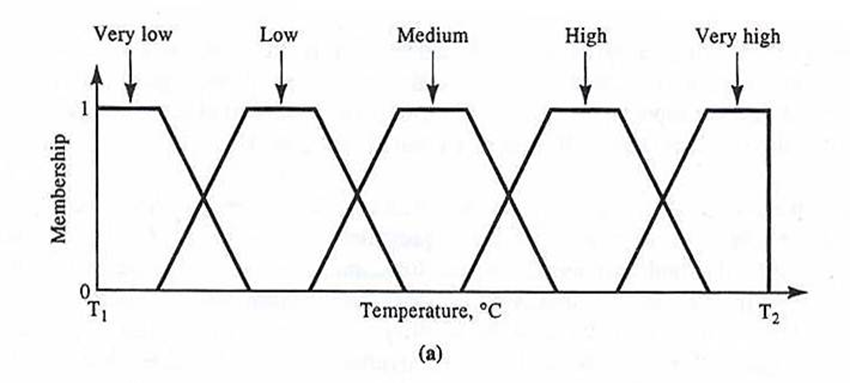

#### Ejercicio 2

Implementa unas funciones que permitan definir las funciones de pertenencia lineal-Z, lineal-S y trapezoidal, y define la variable difusa ```temperatura```:

$\mathcal{D}_{temp} = [-10, 35]$

$temp_{very\_low}(t) = linzmf_{[-5, 0]}(t)$

$temp_{low}(t) = trapmf_{[-5, 0, 5, 10]}(t)$

$temp_{medium}(t) = trapmf_{[5, 10, 15, 20]}(t)$

$temp_{high}(t) = trapmf_{[15, 20, 25, 30]}(t)$

$temp_{very\_high}(t) = linsmf_{[25, 30]}(t)$

In [ ]:
def linzmf(left, right, t):
    ### YOUR CODE HERE
    pass

def linzmf(left_low, left_high, right_high, right_low, t):
    ### YOUR CODE HERE
    pass

def linsmf(left, right, t):
    ### YOUR CODE HERE
    pass

def fuzzy_temp(t):
    ### YOUR CODE HERE
    # temp_verylow = linzmf(-5,0,t)
    # temp_low = trapmf(-5,0,10,15,t)
    # ...
    # return [temp_verylow, temp_low, ...]
    pass

### Conectivas

Al estar definiendo una *extensión* de la lógica clásica, es necesario reformular las **conectivas** lógicas en concordancia (manteniendo los límites clásicos). Las propiedades que deben mantener esas nuevas conectivas son:

* Conmutatividad: $f(a,b) = f(b,a)$
* Asociatividad: $f(a,f(b,c)) = f(f(a,b),c)$
* Monotonía: $a \leq b \Rightarrow f(a,c) \leq f(b,c)$
* Identidad: $\begin{cases} f_{con}(a,1) = a \\ f_{dis}(a,0) = a\end{cases}$

Mientras se respeten los límites clásicos y estas propiedades, se pueden definir conectivas de conjunción ($AND$) y disyunción ($OR$), a las que denominaremos *t-normas* y *t-conormas*, según se quiera. De nuevo, a lo largo de la literatura encontramos algunas definiciones "estándar", normalmente asociadas por pares:

* T-norma: $\top(a,b): \mathcal{D} \rightarrow [0,1]$
  * Mínimo: $\top(a,b) = min\{a,b\}$
  * Łukasiewicz: $\top(a,b) = max\{0, a + b - 1\}$
  * Mínimo nilpotente: $\top(a,b) = \begin{cases} min\{a,b\}  & \text{if \textit{a} + \textit{b} > 1} \\ 0 & \text{otherwise} \end{cases}$

* T-conorma: $\bot(a,b): \mathcal{D} \rightarrow [0,1]$
  * Máximo: $\top(a,b) = max\{a,b\}$
  * Suma acotada: $\bot(a,b) = min\{a + b, 1\}$
  * Máximo nilpotente: $\bot(a,b) = \begin{cases} max\{a,b\}  & \text{if \textit{a} + \textit{b} < 1} \\ 1 & \text{otherwise} \end{cases}$     

#### Ejercicio 3

Escoge una pareja de conectivas lógicas entre (Łukasiewicz, Suma acotada) y (Mínimo nilpotente, Máximo nilpotente) e implementa:
* Comprobación de los límites clásicos
* Visualización en 3D de cada conectiva (los ejes $x$ e $y$ son las entradas, y el eje $z$ es la salida de la función)

In [ ]:
def chosen_tnorm(a,b):
    ### YOUR CODE HERE
    return min(a,b) # THIS IS JUST AN EXAMPLE

def chosen_tconorm(a,b):
    ### YOUR CODE HERE
    return max(a,b) # THIS IS JUST AN EXAMPLE

import numpy as np
import matplotlib.pyplot as plt

fig = plt.figure()
ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122, projection='3d')

# Rango de entradas
a = np.linspace(0, 1, 20)
b = np.linspace(0, 1, 20)

# Malla de dimensiones a x b
A, B = np.meshgrid(a, b)

# Salida de la función
chosen_tnorm_vec = np.vectorize(chosen_tnorm)
Z1 = chosen_tnorm_vec(A,B) 
chosen_tconorm_vec = np.vectorize(chosen_tconorm)
Z2 = chosen_tconorm_vec(A,B) 

# Graficar la malla
ax1.plot_wireframe(A, B, Z1)
ax2.plot_wireframe(A, B, Z2)

plt.show()